In [1]:
import pandas as pd

df = pd.read_csv("Admission_Predict.csv")
df.head()


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [3]:
df['Admit_Label'] = (df['Chance of Admit '] >= 0.70).astype(int)


In [4]:
df.drop(['Serial No.', 'Chance of Admit '], axis=1, inplace=True)


In [5]:
print(df.isnull().sum())


GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Admit_Label          0
dtype: int64


In [6]:
df['GRE Score'].fillna(df['GRE Score'].mean(), inplace=True)


In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
features = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research']
df[features] = scaler.fit_transform(df[features])


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('Admit_Label', axis=1)  # Features
y = df['Admit_Label']               # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [10]:
y_pred = model.predict(X_test)


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88        32
           1       0.92      0.92      0.92        48

    accuracy                           0.90        80
   macro avg       0.90      0.90      0.90        80
weighted avg       0.90      0.90      0.90        80

Confusion Matrix:
 [[28  4]
 [ 4 44]]


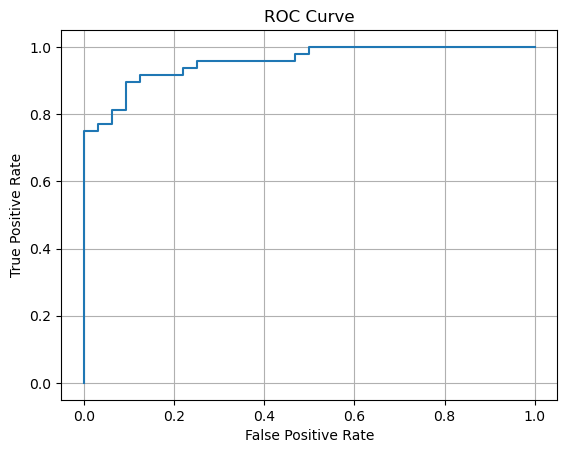

ROC-AUC Score: 0.9563802083333333


In [13]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))


In [14]:
sample = [[0.85, 0.90, 0.8, 0.7, 0.75, 0.88, 1]]  # Normalized values
pred = model.predict(sample)
print("Admitted" if pred[0] == 1 else "Not Admitted")


Admitted


/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
